In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats  # It is used for drawing the QQ plot

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score # it split your data into k times then run your model k times

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [8]:
# importing PowerTransformer
from sklearn.preprocessing import PowerTransformer # this contains both box-cox as well as yeo-johnson

In [10]:
data = pd.read_csv('../../datasets/concrete_data.csv')

In [11]:
data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [12]:
data.shape

(1030, 9)

In [13]:
data.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [15]:
# This is used for analysing all the hidden values of the data
data.describe()
#Note -> box-cox transformer their  should be only positive values

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [16]:
data.head(3)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27


In [17]:
x = data.drop(columns=['Strength'])
y = data.iloc[:,8:9]

In [18]:
x.head(3)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270


In [19]:
y.head(3)

,Strength
0,79.99
1,61.89
2,40.27


In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [23]:
# Applying linear regression without any kind of transformer
LR = LinearRegression()
LR.fit(x_train,y_train)
y_pred = LR.predict(x_test)  # make predixtion on x_test data  
r2_score(y_test,y_pred)

0.5943782479239204

In [25]:
# cross checking the ans with cross val score
np.mean(cross_val_score(LR,x,y,scoring='r2'))
# After cross checking it gives the answer that is suitation is too bad rather that prediction

np.float64(0.4609940491662864)

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


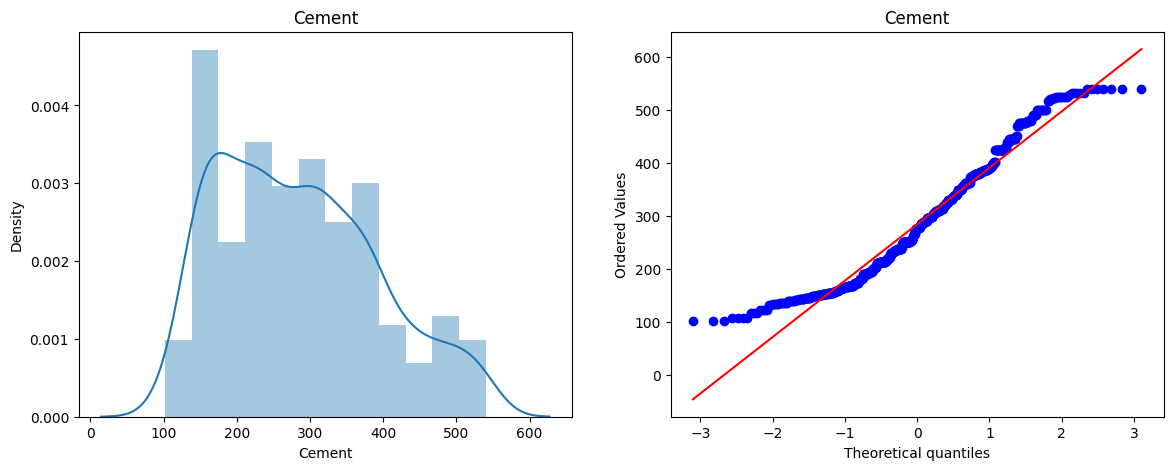

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


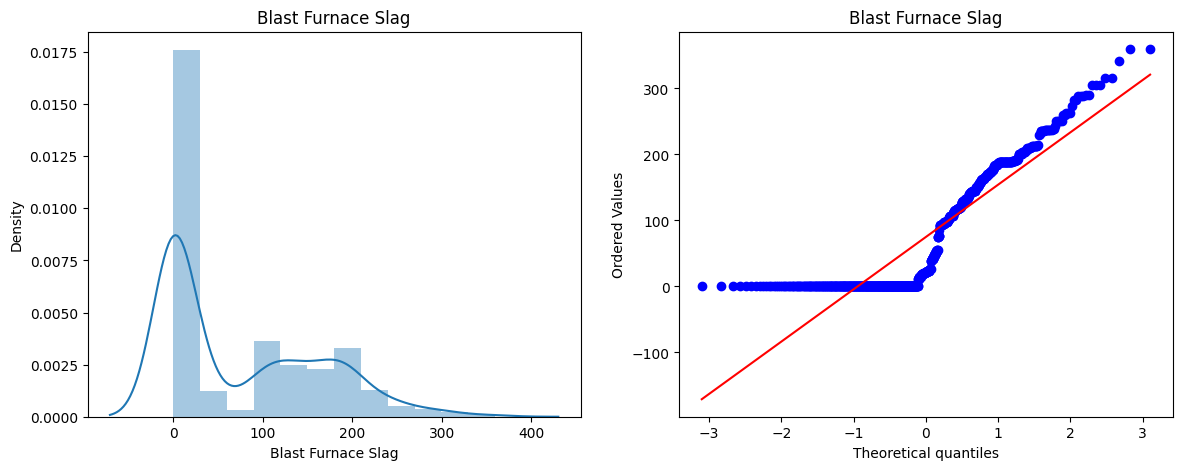

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


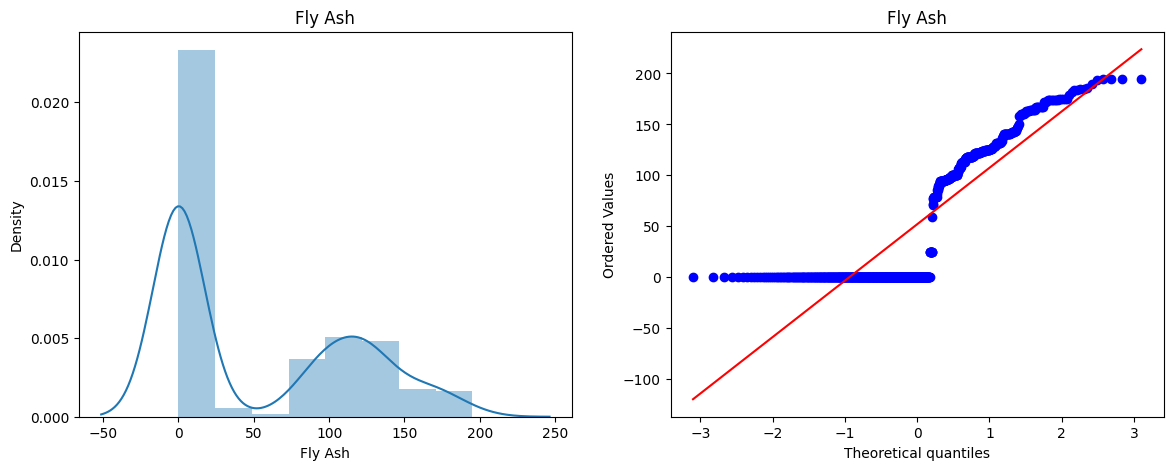

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


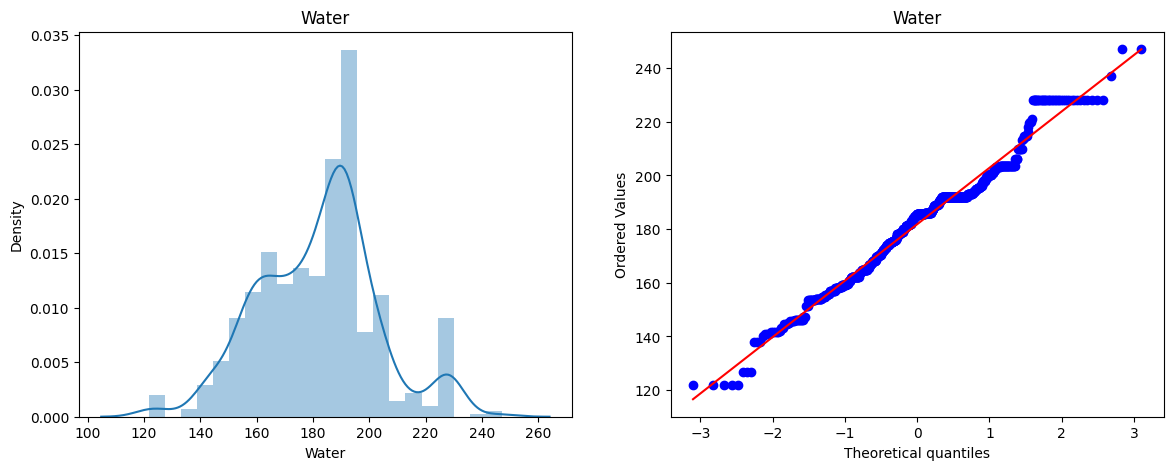

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


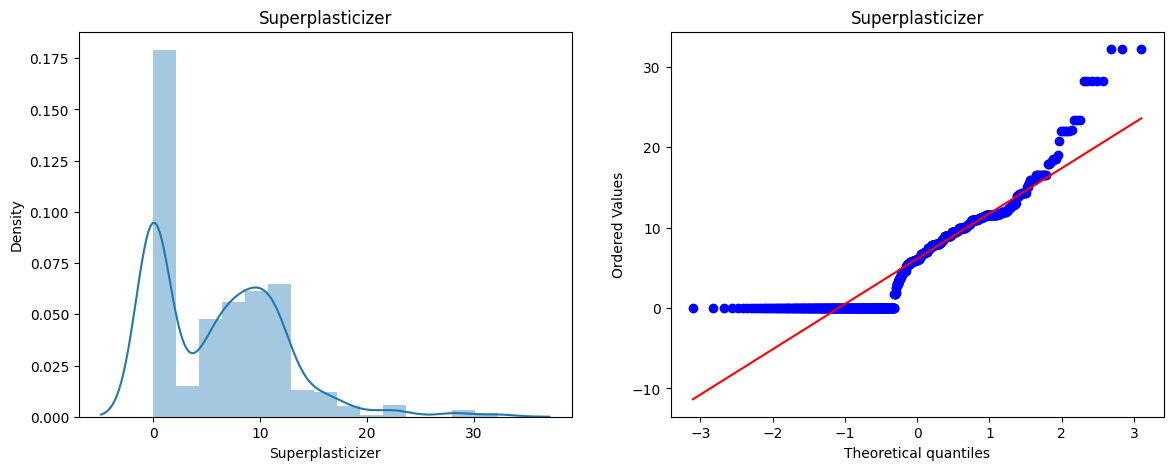

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


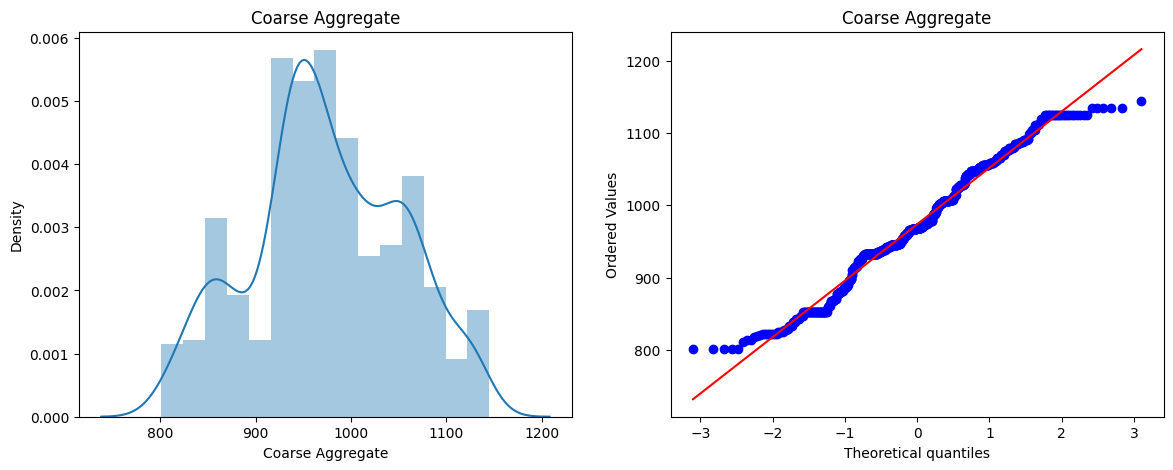

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


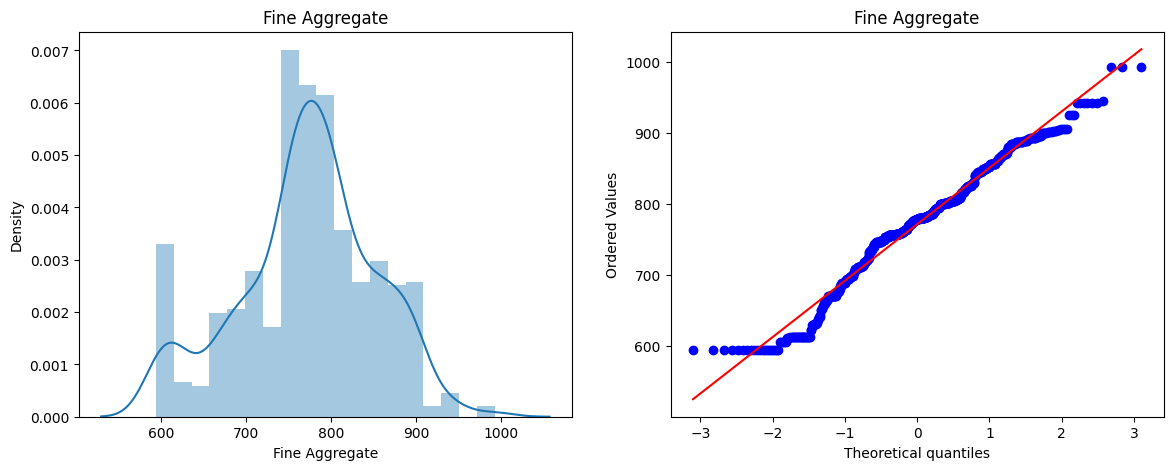

C:\Users\dspri\AppData\Local\Temp\ipykernel_14888\408345581.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


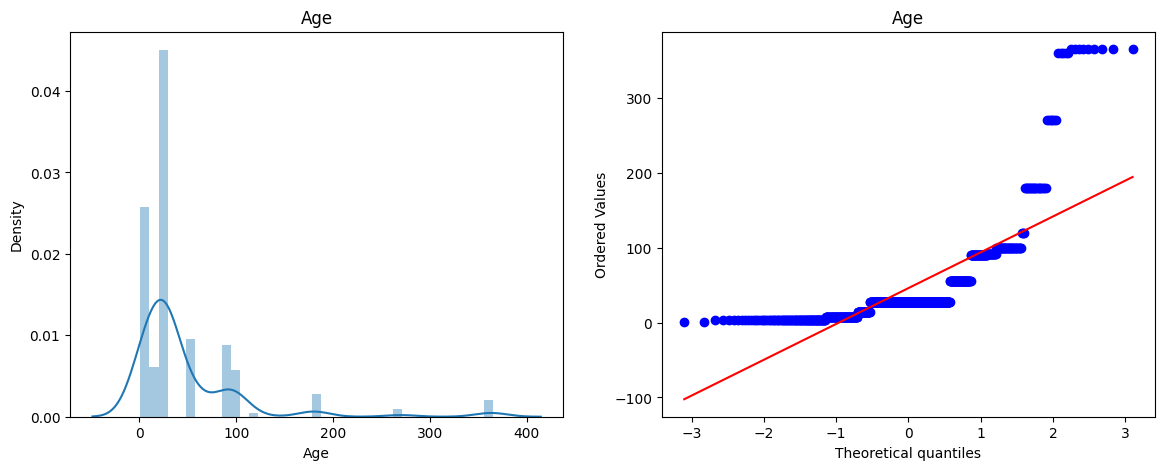

In [26]:
# ploting distplot without any kind of transformer
for col in x_train.columns:
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    sns.distplot(x_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x_train[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()

In [29]:
# Applying box-cos transformation over data
pt = PowerTransformer(method='box-cox')
x_train_transformed = pt.fit_transform(x_train + 0.00001)  # We are adding 0.00001 here because their are some 0 values are
# present in the data and we can not apply box-cox transformer over this.
x_test_transformed = pt.fit_transform(x_test +  0.000001)
pd.DataFrame({'cols': x_train.columns,'box-cox-lambda':pt.lambdas_})# this makes a mini column of your datasets and write the
# show the lambda value of each feture which is calculated during the the PowerTransformer.

,cols,box-cox-lambda
0,Cement,0.152937
1,Blast Furnace Slag,0.024148
2,Fly Ash,-0.003482
3,Water,0.690936
4,Superplasticizer,0.115747
5,Coarse Aggregate,1.391687
6,Fine Aggregate,1.704798
7,Age,-0.004437


In [31]:
# We have applied numpy operation that why our data converted into numpy for that data again we have to convert data again in data frame.

In [32]:
x_train_transformed

array([[-0.79294118, -1.08717463,  1.13791169, ...,  0.4142525 ,
         1.7791873 ,  0.07028264],
       [ 0.50467924, -1.08717463, -0.87077687, ...,  1.13754686,
         0.09763807, -1.06749537],
       [ 0.45353565,  1.01426086, -0.87077687, ..., -1.5489629 ,
         1.41239576, -1.70934281],
       ...,
       [-0.84788833, -1.08717463,  1.15538009, ...,  1.34229665,
         0.30288539,  1.21922253],
       [ 1.55218633,  0.92374449, -0.87077687, ..., -1.5489629 ,
         0.07846487,  0.07028264],
       [ 0.41338676, -1.08717463,  1.14725496, ..., -0.6230693 ,
         0.09763807,  0.07028264]], shape=(721, 8))

In [33]:
# before and after comparision of the using the box-cox transformation
x_train_transformed = pd.DataFrame(x_train_transformed,columns=x_train.columns)


In [34]:
x_train_transformed

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,-0.792941,-1.087175,1.137912,-0.762515,0.722325,0.414253,1.779187,0.070283
1,0.504679,-1.087175,-0.870777,0.112145,-1.281340,1.137547,0.097638,-1.067495
2,0.453536,1.014261,-0.870777,-1.238953,0.909840,-1.548963,1.412396,-1.709343
3,0.771927,0.648060,1.164745,-1.321206,0.829370,-0.406723,0.330268,-1.709343
4,-1.228110,0.996723,1.168547,-0.124211,0.996616,-1.727686,-0.426811,0.070283
...,...,...,...,...,...,...,...,...
716,0.171508,1.005457,-0.870777,-1.773579,0.837312,0.391277,0.365568,-1.709343
717,-0.208381,-1.087175,1.155317,-1.842041,0.857599,1.442157,0.328963,-0.512707
718,-0.847888,-1.087175,1.155380,-0.714626,0.801406,1.342297,0.302885,1.219223
719,1.552186,0.923744,-0.870777,-0.024825,0.770796,-1.548963,0.078465,0.070283


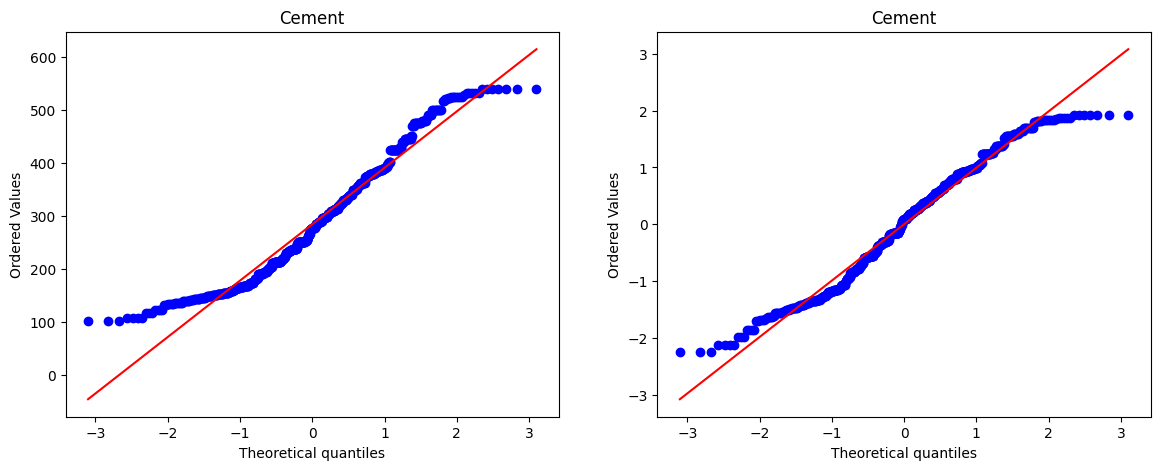

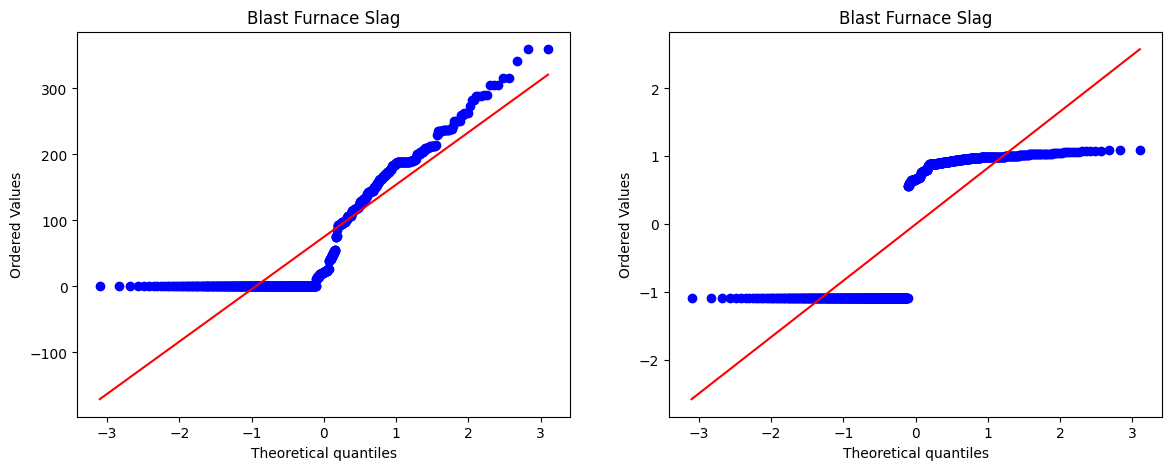

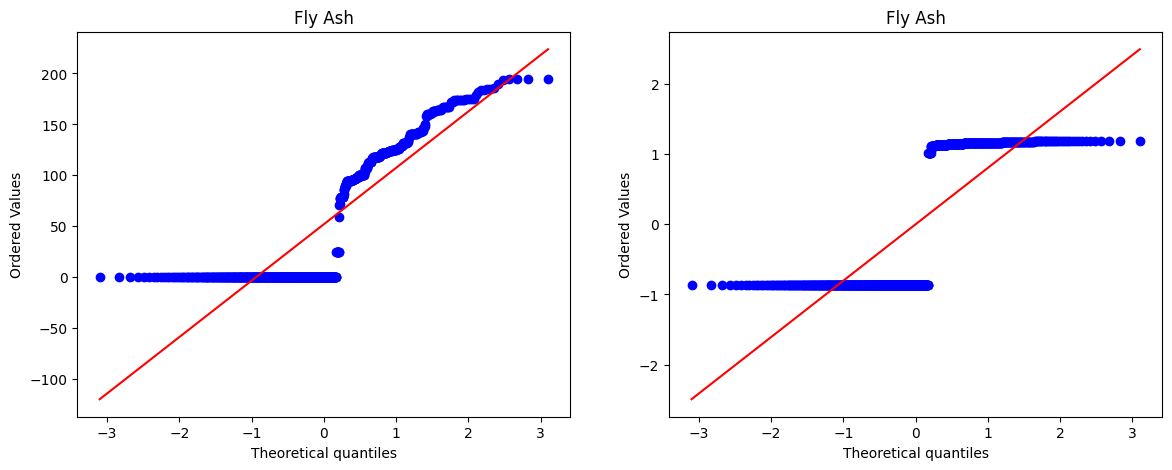

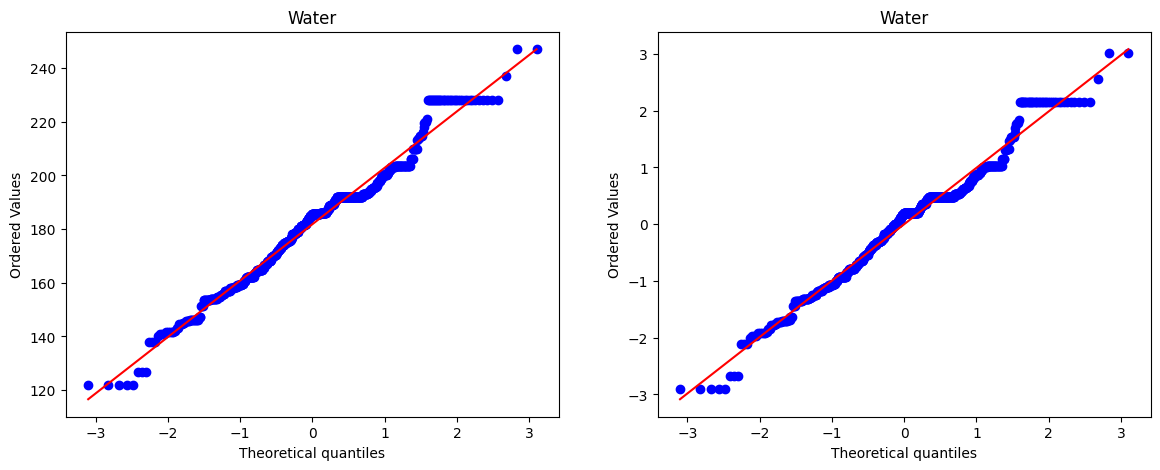

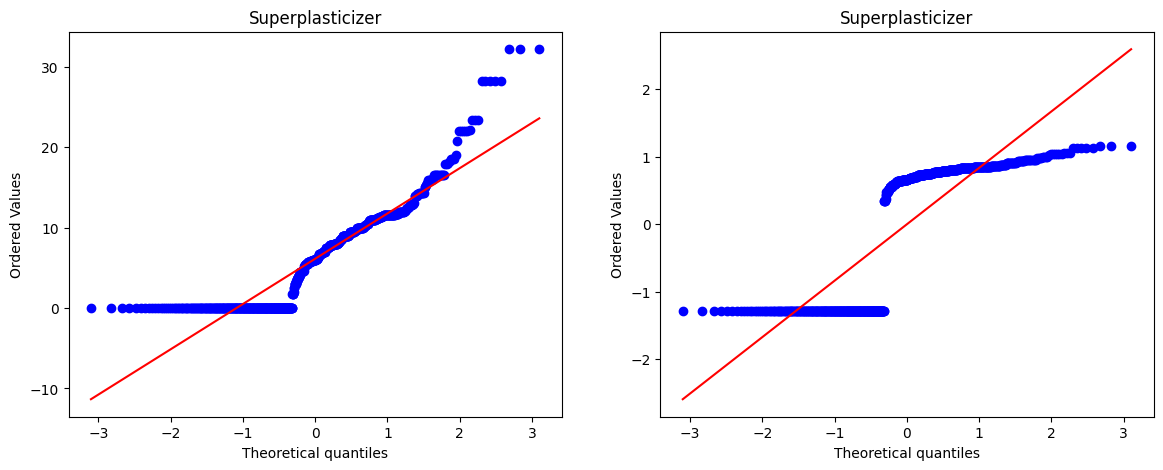

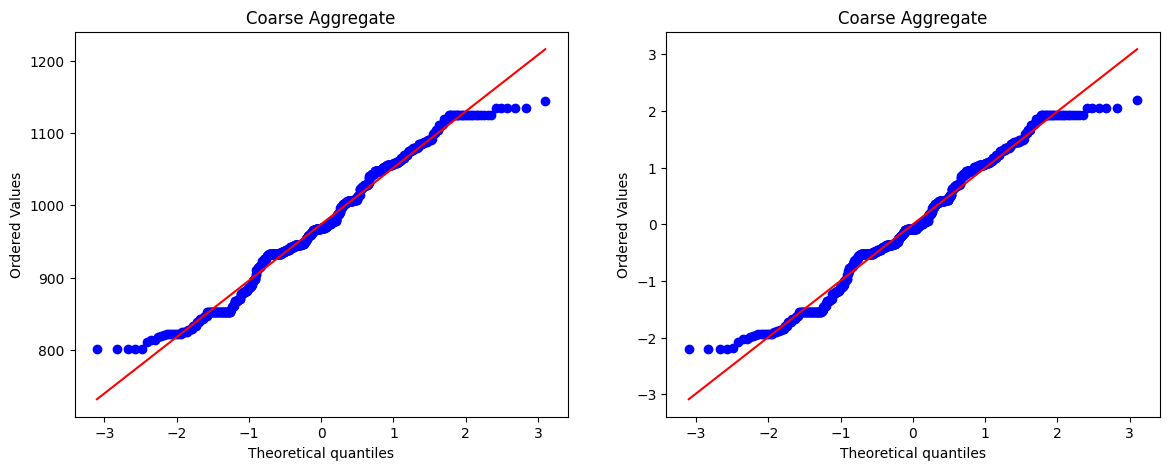

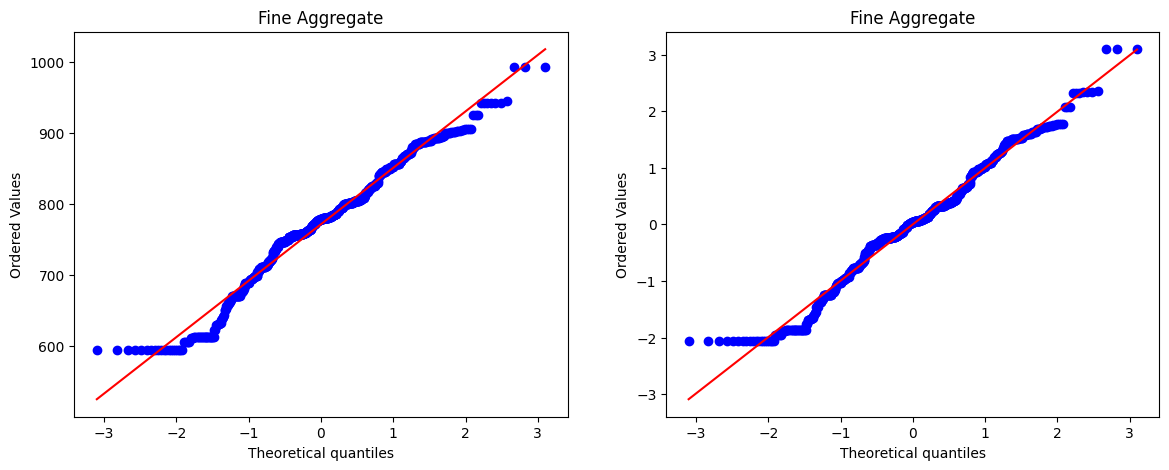

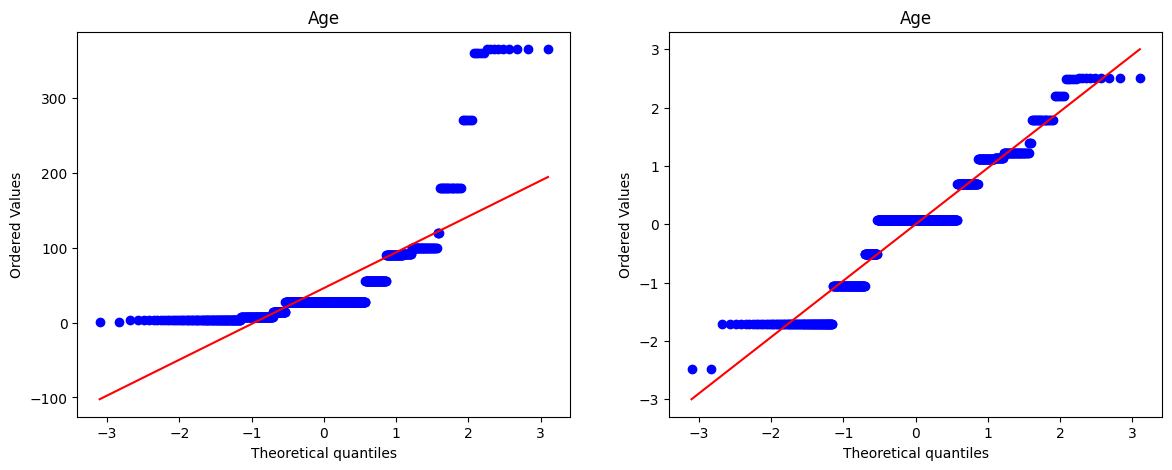

In [36]:
# drawing plot before and after transformaton
for col in x_train_transformed.columns:
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    stats.probplot(x_train[col],dist='norm',plot=plt)
    plt.title(col)
    # second plot
    plt.subplot(1,2,2)
    stats.probplot(x_train_transformed[col],dist='norm',plot=plt)
    plt.title(col)

    plt.show()
    

In [ ]:
# draw the distplot before and after applying the box-cox trasformer
